In [2]:
# Install PyTorch Geometric dependencies
!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install -q torch-cluster -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install -q torch-spline-conv -f https://data.pyg.org/whl/torch-2.2.0+cpu.html

# Then install main package
!pip install -q torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.5/511.5 kB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 774.1/774.1 kB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.4/215.4 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.3 MB/s eta 0:00:00


In [3]:
#IMPORTS
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import gzip
from torch_geometric.data import HeteroData
import torch.nn as nn
from torch_geometric.nn import HeteroConv, GCNConv, SAGEConv
import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import networkx as nx
import torch_geometric.transforms as T
from sklearn.preprocessing import StandardScaler

/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cpu.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_cluster/_version_cpu.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_spline_conv/_version_cpu.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue oc

In [4]:
!pip install -q gcsfs pyarrow

In [5]:
from google.colab import auth
auth.authenticate_user()

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Define base paths
CYBER_PATH = "gs://lanl-cyber-dataset-team12/"
ELLIPTIC_PATH = '/content/drive/MyDrive/archive/elliptic_bitcoin_dataset/'

# Load Elliptic Bitcoin Data (Baseline)
# Classes: map nodes to 'licit', 'illicit', or 'unknown'
elliptic_classes = pd.read_csv(f'{ELLIPTIC_PATH}elliptic_txs_classes.csv')

# Edges: source -> destination transactions
elliptic_edges = pd.read_csv(f'{ELLIPTIC_PATH}elliptic_txs_edgelist.csv')

# Features: 166-dim node features (first col is node_id)
# Note: Loading only the first 50,000 to keep it snappy for the prototype
elliptic_features = pd.read_csv(f'{ELLIPTIC_PATH}elliptic_txs_features.csv', header=None)

# Load LANL Cyber Data (Behavioral Layers)


# Flow: Parquet is pre-optimized for fast reading
flow_df = pd.read_parquet(CYBER_PATH+'flow.parquet')

# Load Ground Truth Labels (Absolute Need)
redteam_df = pd.read_csv(CYBER_PATH + 'redteam.txt.gz', compression='gzip', header=None,
                        names=['time', 'user', 'src_comp', 'dst_comp'])

print(" Datasets successfully loaded from /data/ subfolders!")
print(f"Elliptic Classes: {elliptic_classes.shape}")
print(f"Redteam Ground Truth: {redteam_df.shape}")
print(f"Flow Data: {flow_df.shape}")

 Datasets successfully loaded from /data/ subfolders!
Elliptic Classes: (203769, 2)
Redteam Ground Truth: (749, 4)
Flow Data: (129977412, 9)


In [8]:
print("Loading a contiguous chunk of data preserving all information...")

# Load the first 5 million rows (you can adjust this number based on available RAM)
auth_df = pd.read_csv(CYBER_PATH + 'auth.txt.gz', compression='gzip', nrows=5000000, header=None,
                     names=['time', 'src_user', 'dst_user', 'src_comp', 'dst_comp',
                            'auth_type', 'logon_type', 'auth_orientation', 'success'])

print(f"\nFinished! Loaded {len(auth_df):,} authentication events.")
print(f"Machine accounts (containing '$') are now included in the graph.")
display(auth_df.head())

Loading a contiguous chunk of data preserving all information...

Finished! Loaded 5,000,000 authentication events.
Machine accounts (containing '$') are now included in the graph.


,time,src_user,dst_user,src_comp,dst_comp,auth_type,logon_type,auth_orientation,success
0,1,ANONYMOUS LOGON@C586,ANONYMOUS LOGON@C586,C1250,C586,NTLM,Network,LogOn,Success
1,1,ANONYMOUS LOGON@C586,ANONYMOUS LOGON@C586,C586,C586,?,Network,LogOff,Success
2,1,C101$@DOM1,C101$@DOM1,C988,C988,?,Network,LogOff,Success
3,1,C1020$@DOM1,SYSTEM@C1020,C1020,C1020,Negotiate,Service,LogOn,Success
4,1,C1021$@DOM1,C1021$@DOM1,C1021,C625,Kerberos,Network,LogOn,Success


In [9]:
auth_df['time'].max()

34010

In [10]:
#  Get unique entities from Cyber Dataset
unique_users = auth_df['src_user'].unique()
unique_comps = pd.unique(auth_df[['src_comp', 'dst_comp']].values.ravel('K'))

#  Get unique entities from Bitcoin Dataset
unique_wallets = elliptic_classes['txId'].unique()

#  Create mapping dictionaries (to convert IDs to 0-indexed integers for the GNN)
user_map = {id: i for i, id in enumerate(unique_users)}
comp_map = {id: i for i, id in enumerate(unique_comps)}
wallet_map = {id: i for i, id in enumerate(unique_wallets)}

print(f"Unique Users: {len(unique_users)}")
print(f"Unique Computers: {len(unique_comps)}")
print(f"Unique Wallets: {len(unique_wallets)}")

Unique Users: 27187
Unique Computers: 9096
Unique Wallets: 203769


# Next, we will match TimeStamps
Since the LANL dataset spans roughly 58 days ($5,011,199$ seconds) and the Elliptic dataset has 49 steps, we will divide the LANL time into 49 equal segments.

In [11]:
#  Define the maximum time in the LANL auth sample
max_lanl_time = auth_df['time'].max()

#  Create the 49 bins (Elliptic has 49 time steps)
# We use linspace to create boundaries and digitize to assign rows to bins
bins = np.linspace(0, max_lanl_time, num=50) # 50 boundaries create 49 bins

#  Apply binning to Auth and Redteam data
auth_df['time_step'] = np.digitize(auth_df['time'], bins)
redteam_df['time_step'] = np.digitize(redteam_df['time'], bins)

#  Check the distribution
print(f"Auth data now binned into {auth_df['time_step'].nunique()} time steps.")
print(f"Example mapping: Auth Time {auth_df['time'].iloc[0]} -> Step {auth_df['time_step'].iloc[0]}")

#  Quick validation: Does the Redteam data fall within these steps?
print(f"Redteam steps range: {redteam_df['time_step'].min()} to {redteam_df['time_step'].max()}")

Auth data now binned into 50 time steps.
Example mapping: Auth Time 1 -> Step 1
Redteam steps range: 50 to 50


Auth Sample Time Range: 1 to 34010
Redteam Full Time Range: 150885 to 2557047
Redteam events within Auth Sample window: 0


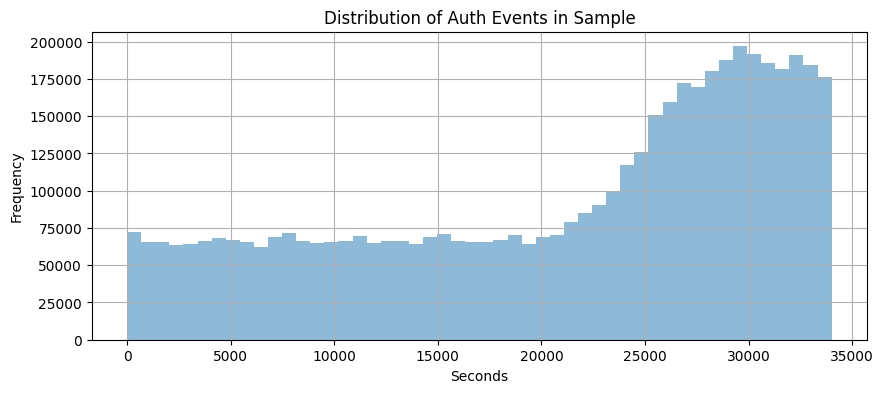


Auth Success/Failure Counts:
success
Success    4963653
Fail         36347
Name: count, dtype: int64


In [12]:
# Check the actual time range of both datasets
print(f"Auth Sample Time Range: {auth_df['time'].min()} to {auth_df['time'].max()}")
print(f"Redteam Full Time Range: {redteam_df['time'].min()} to {redteam_df['time'].max()}")

#  Count how many Redteam events actually fall within our Auth Sample window
events_in_sample = redteam_df[redteam_df['time'] <= auth_df['time'].max()]
print(f"Redteam events within Auth Sample window: {len(events_in_sample)}")

#  Visualize the 'Density' of activity in the Auth sample
plt.figure(figsize=(10, 4))
auth_df['time'].hist(bins=50, alpha=0.5, label='Auth Events')
plt.title("Distribution of Auth Events in Sample")
plt.xlabel("Seconds")
plt.ylabel("Frequency")
plt.show()

# Check for 'Success' vs 'Failure' ratio in Auth (Key for ATO detection)
print("\nAuth Success/Failure Counts:")
print(auth_df['success'].value_counts())

In [13]:
import gcsfs
import gzip
# Get the time windows where Redteam activity actually happens
min_attack = redteam_df['time'].min()
max_attack = redteam_df['time'].max()

# Targeted extraction: Grab rows near the attack times
dense_auth_rows = []
#with gzip.open('./data/cyber_dataset/auth.txt.gz', 'rt') as f:
fs = gcsfs.GCSFileSystem()

with fs.open('lanl-cyber-dataset-team12/auth.txt.gz', 'rb') as gcs_file:
    with gzip.open(gcs_file, 'rt') as f:

        for i, line in enumerate(f):
            parts = line.strip().split(',')
            t = int(parts[0])

            # Keep first 100k for background
            if i < 500000:
                dense_auth_rows.append(parts)

            # Keep rows during the Redteam attack window
            elif min_attack <= t <= max_attack:
                # To keep it manageable, we sample every 10th row in the attack window
                if i % 10 == 0:
                    dense_auth_rows.append(parts)

            # Stop if we hit a reasonable local limit for your Mac (e.g., 600k rows)
            if len(dense_auth_rows) >= 600000:
                break


#  Rebuild the dataframe
auth_df = pd.DataFrame(dense_auth_rows, columns=['time', 'src_user', 'dst_user', 'src_comp', 'dst_comp',
                                                 'auth_type', 'logon_type', 'auth_orientation', 'success'])
auth_df['time'] = auth_df['time'].astype(int)

print(f"New Auth Sample Size: {len(auth_df)}")
print(f"New Time Range: {auth_df['time'].min()} to {auth_df['time'].max()}")

# Re-check the overlap
events_in_sample = redteam_df[redteam_df['time'] <= auth_df['time'].max()]
print(f"Redteam events now within Auth Sample window: {len(events_in_sample)}")

New Auth Sample Size: 600000
New Time Range: 1 to 156435
Redteam events now within Auth Sample window: 9


In [15]:
flow_df.head()

,time,duration,source_computer,source_port,destination_computer,destination_port,protocol,packet_count,byte_count
0,1,0,C1065,389,C3799,N10451,6,10,5323
1,1,0,C1423,N1136,C1707,N1,6,5,847
2,1,0,C1423,N1142,C1707,N1,6,5,847
3,1,0,C14909,N8191,C5720,2049,6,1,52
4,1,0,C14909,N8192,C5720,2049,6,1,52


In [16]:
#  Get the specific users and computers involved in the 10 Redteam events
rt_sample = redteam_df[redteam_df['time'] <= auth_df['time'].max()]
rt_users = rt_sample['user'].unique()
rt_comps = rt_sample['src_comp'].unique()

#  Check if these users/computers exist in our Auth activity log
users_present = auth_df[auth_df['src_user'].isin(rt_users)]['src_user'].nunique()
comps_present = auth_df[auth_df['src_comp'].isin(rt_comps)]['src_comp'].nunique()

print(f"Redteam Users found in Auth Sample: {users_present} out of {len(rt_users)}")
print(f"Redteam Computers found in Auth Sample: {comps_present} out of {len(rt_comps)}")

# Label the Auth data
# We mark a row as '1' if it matches a Redteam event (User + Computer + Time)
auth_df['is_redteam'] = 0
for idx, row in rt_sample.iterrows():
    mask = (auth_df['src_user'] == row['user']) & \
           (auth_df['src_comp'] == row['src_comp']) & \
           (auth_df['time'] == row['time'])
    auth_df.loc[mask, 'is_redteam'] = 1

print(f"Total confirmed 'Attack' edges in Auth Graph: {auth_df['is_redteam'].sum()}")

# --- NEW: Process flow_df alongside auth_df ---
# Filter flow_df to match the auth sample time window to save memory
flow_sample = flow_df[flow_df['time'] <= auth_df['time'].max()].copy()
print(f"\nFlow Sample Size: {len(flow_sample)} out of {len(flow_df)}")

# Check if redteam computers exist in the flow sample
flow_comps_present = flow_sample[flow_sample['source_computer'].isin(rt_comps)]['source_computer'].nunique()
print(f"Redteam Computers found in Flow Sample: {flow_comps_present} out of {len(rt_comps)}")

# Label the Flow data
flow_sample['is_redteam'] = 0
for idx, row in rt_sample.iterrows():
    mask = (flow_sample['source_computer'] == row['src_comp']) & \
           (flow_sample['destination_computer'] == row['dst_comp']) & \
           (flow_sample['time'] == row['time'])
    flow_sample.loc[mask, 'is_redteam'] = 1

print(f"Total confirmed 'Attack' edges in Flow Graph: {flow_sample['is_redteam'].sum()}")


Redteam Users found in Auth Sample: 4 out of 4
Redteam Computers found in Auth Sample: 1 out of 1
Total confirmed 'Attack' edges in Auth Graph: 1

Flow Sample Size: 17192575 out of 129977412
Redteam Computers found in Flow Sample: 1 out of 1
Total confirmed 'Attack' edges in Flow Graph: 0


# This is better!
We need to convert our User and Computer IDs into a format for the GNN

In [17]:
# Update our Mapping dictionaries with the latest sample
unique_users = auth_df['src_user'].unique()
unique_comps = pd.unique(auth_df[['src_comp', 'dst_comp']].values.ravel('K'))

user_map = {id: i for i, id in enumerate(unique_users)}
comp_map = {id: i for i, id in enumerate(unique_comps)}

# Convert Auth Log into Edge Lists
# We are building a Bipartite Graph: User -> Computer
src_indices = auth_df['src_user'].map(user_map).values
dst_indices = auth_df['src_comp'].map(comp_map).values

#  Create the Edge Index Tensor
edge_index_user_to_comp = torch.tensor([src_indices, dst_indices], dtype=torch.long)

print(f"Graph Adjacency Matrix created.")
print(f"Total Edges (User -> Computer): {edge_index_user_to_comp.shape[1]}")
print(f"Example Edge: User {src_indices[0]} accessed Computer {dst_indices[0]}")

Graph Adjacency Matrix created.
Total Edges (User -> Computer): 600000
Example Edge: User 0 accessed Computer 0


/tmp/ipykernel_639/2042265391.py:14: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  edge_index_user_to_comp = torch.tensor([src_indices, dst_indices], dtype=torch.long)


In [18]:
#  Pick a few illicit Bitcoin nodes
illicit_txs = elliptic_classes[elliptic_classes['class'] == '1']['txId'].values

# Pick the 'Compromised' computers from our Auth sample
compromised_comps = auth_df[auth_df['is_redteam'] == 1]['src_comp'].unique()

#  Create the Synthetic Bridge
# We link these specific Bitcoin transactions to these specific Computers
bridge_edges = []
for tx in illicit_txs[:100]: # Linking the first 100 for the prototype
    for comp in compromised_comps:
        bridge_edges.append([wallet_map[tx], comp_map[comp]])

edge_index_bridge = torch.tensor(bridge_edges, dtype=torch.long).t().contiguous()

print(f"Synthetic Bridge Created.")
print(f"Total Cross-Channel Edges: {edge_index_bridge.shape[1]}")

Synthetic Bridge Created.
Total Cross-Channel Edges: 100


In [19]:
#  Initialize the HeteroData object
data = HeteroData()

#  Add Node Sets
# For the prototype, we use placeholder features (identity matrices)
data['transaction'].num_nodes = len(unique_wallets)
data['user'].num_nodes = len(unique_users)
data['computer'].num_nodes = len(unique_comps)

# Add Edges (Intra-layer)
# Bitcoin internal transactions (from your elliptic_edges)
# Note: We use the wallet_map to ensure IDs match
btc_src = elliptic_edges['txId1'].map(wallet_map).values
btc_dst = elliptic_edges['txId2'].map(wallet_map).values
data['transaction', 'transacts_with', 'transaction'].edge_index = torch.tensor([btc_src, btc_dst], dtype=torch.long)

# Cyber internal authentication (User -> Computer)
data['user', 'authenticates_to', 'computer'].edge_index = edge_index_user_to_comp

# 4. Add the Synthetic Bridge (Cross-layer)
data['transaction', 'accessed_via', 'computer'].edge_index = edge_index_bridge

print("HeteroData Object Finalized")
print(data)

HeteroData Object Finalized
HeteroData(
  transaction={ num_nodes=203769 },
  user={ num_nodes=14175 },
  computer={ num_nodes=8256 },
  (transaction, transacts_with, transaction)={ edge_index=[2, 234355] },
  (user, authenticates_to, computer)={ edge_index=[2, 600000] },
  (transaction, accessed_via, computer)={ edge_index=[2, 100] }
)


In [20]:
# --- Integrating Network Flow into the Graph Layer ---

import numpy as np

# 1. Filter the flow data to only include computers we already know about in our graph
# This saves memory and prevents dimension mismatches
known_flow = flow_sample[
    flow_sample['source_computer'].isin(comp_map.keys()) &
    flow_sample['destination_computer'].isin(comp_map.keys())
].copy()

# 2. Map the computer names to their integer IDs used in the graph
src_comp_indices = known_flow['source_computer'].map(comp_map).values
dst_comp_indices = known_flow['destination_computer'].map(comp_map).values

# 3. Create the Edge Index Tensor for network traffic
# Converting to a single numpy array first fixes the PyTorch UserWarning
edge_index_flow = torch.tensor(np.array([src_comp_indices, dst_comp_indices]), dtype=torch.long)

# 4. Add the new relationship layer to our existing HeteroData object
data['computer', 'connects_to', 'computer'].edge_index = edge_index_flow

print(f"Added Network Flow Layer!")
print(f"Total Network Connections (Computer -> Computer): {edge_index_flow.shape[1]}")
print(data)

Added Network Flow Layer!
Total Network Connections (Computer -> Computer): 9917448
HeteroData(
  transaction={ num_nodes=203769 },
  user={ num_nodes=14175 },
  computer={ num_nodes=8256 },
  (transaction, transacts_with, transaction)={ edge_index=[2, 234355] },
  (user, authenticates_to, computer)={ edge_index=[2, 600000] },
  (transaction, accessed_via, computer)={ edge_index=[2, 100] },
  (computer, connects_to, computer)={ edge_index=[2, 9917448] }
)


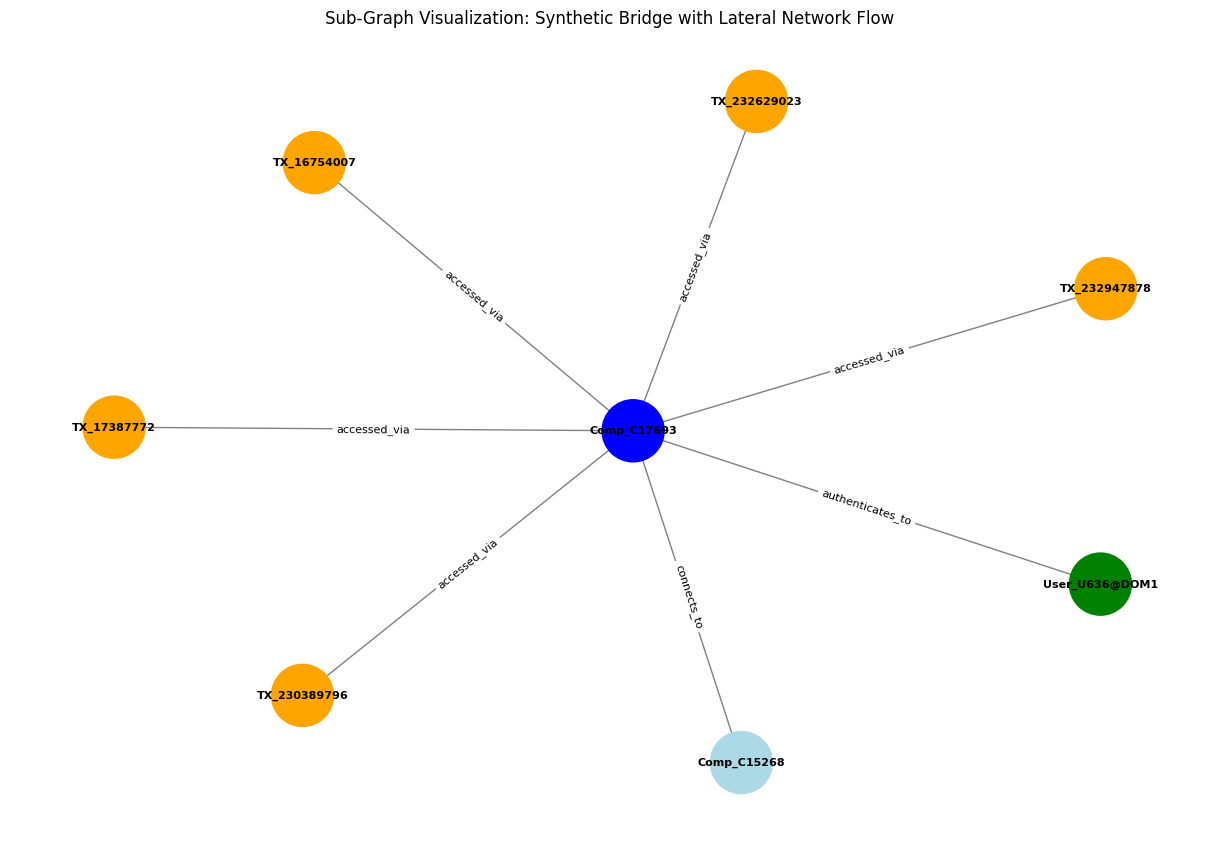

In [21]:
import networkx as nx
import matplotlib.pyplot as plt

# Create an empty NetworkX graph
G = nx.Graph()

# We will visualize just a small subset of the 'Bridge'
# Get the first 5 cross-layer edges (Transaction -> Computer)
bridge_edges = edge_index_bridge[:, :5]

# Add the edges to the graph with prefixes to distinguish node types
for i in range(bridge_edges.shape[1]):
    tx_idx = bridge_edges[0, i].item()
    comp_idx = bridge_edges[1, i].item()

    # Get original IDs for labels
    tx_id = f"TX_{unique_wallets[tx_idx]}"
    comp_id = f"Comp_{unique_comps[comp_idx]}"

    G.add_node(tx_id, type='transaction', color='orange')
    G.add_node(comp_id, type='computer', color='blue')
    G.add_edge(tx_id, comp_id, label='accessed_via')

# Add a few users who authenticated to this compromised computer
comp_idx = bridge_edges[1, 0].item() # The compromised computer index
comp_id = f"Comp_{unique_comps[comp_idx]}"

# Find users linked to this computer
auth_edges = edge_index_user_to_comp
linked_users = auth_edges[0, auth_edges[1] == comp_idx][:3] # Get up to 3 users

for u_idx in linked_users:
    user_id = f"User_{unique_users[u_idx]}"
    G.add_node(user_id, type='user', color='green')
    G.add_edge(user_id, comp_id, label='authenticates_to')

# --- NEW: Add 2-3 other computers connected via network flow ---
# This will show the lateral movement from the compromised computer
flow_edges = edge_index_flow
connected_comps = flow_edges[1, flow_edges[0] == comp_idx][:3] # Get up to 3 connected computers

for c_idx in connected_comps:
    c_id = f"Comp_{unique_comps[c_idx]}"
    G.add_node(c_id, type='computer', color='lightblue') # Light blue to distinguish from the main compromised one
    G.add_edge(comp_id, c_id, label='connects_to')

# --- Plotting ---
plt.figure(figsize=(12, 8))
# Use spring layout to position nodes nicely
pos = nx.spring_layout(G, seed=42)

# Extract node colors based on their type
colors = [nx.get_node_attributes(G, 'color').get(node, 'gray') for node in G.nodes()]

# Draw nodes and edges
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=2000,
        font_size=8, font_weight='bold', edge_color='gray')

# Draw edge labels
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Sub-Graph Visualization: Synthetic Bridge with Lateral Network Flow")
plt.show()

In [22]:
import torch_geometric.transforms as T

# Transform the graph to be undirected so messages can flow both ways
data = T.ToUndirected()(data)

class FraudGNN(nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super().__init__()
        # Dynamically create SAGEConv for all edge types (including the new reverse edges)
        self.conv1 = HeteroConv({
            edge_type: SAGEConv(-1, hidden_channels) for edge_type in data.edge_types
        }, aggr='sum')

        self.lin = nn.Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        # x_dict is a dictionary of node features for each type
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: x.relu() for key, x in x_dict.items()}
        return self.lin(x_dict['transaction']) # We care about classifying transactions

# Initialize the model
model = FraudGNN(hidden_channels=64, out_channels=2)
print("Heterogeneous GNN Architecture Initialized with Bidirectional Edges!")

Heterogeneous GNN Architecture Initialized with Bidirectional Edges!


In [23]:

# Define illicit_nodes from the dataframe
# In Elliptic: '1' is illicit, '2' is licit, 'unknown' is unknown
illicit_nodes = elliptic_classes[elliptic_classes['class'] == '1']['txId'].values

#  Attach Elliptic Features to 'transaction' nodes
# We use the mapping to ensure the features align with the graph indices
feature_matrix = torch.zeros((len(unique_wallets), 166))

# Optimization: Convert elliptic_features to a dictionary for O(1) lookup
# Assuming column 0 is txId and the rest are features
feat_dict = dict(zip(elliptic_features[0], elliptic_features.iloc[:, 1:].values))

for i, tx_id in enumerate(unique_wallets):
    if tx_id in feat_dict:
        feature_matrix[i] = torch.tensor(feat_dict[tx_id], dtype=torch.float)

data['transaction'].x = feature_matrix

# Attach Lightweight Identity Features for Cyber nodes (User/Computer)
# Using random normal instead of torch.eye to save memory
data['user'].x = torch.randn(len(unique_users), 16)
data['computer'].x = torch.randn(len(unique_comps), 16)

# Define Labels (Target)
labels = torch.zeros(len(unique_wallets), dtype=torch.long)
illicit_indices = [wallet_map[tx] for tx in illicit_nodes if tx in wallet_map]
labels[illicit_indices] = 1
data['transaction'].y = labels

print(f"Features attached. Illicit nodes labeled: {len(illicit_indices)}")

Features attached. Illicit nodes labeled: 4545


In [24]:
tx_to_step_map = dict(zip(elliptic_features[0], elliptic_features[1]))

tx_timesteps = torch.zeros(len(unique_wallets), dtype=torch.long)

for i, tx_id in enumerate(unique_wallets):
    tx_timesteps[i] = tx_to_step_map.get(tx_id, 0)

data['transaction'].time_step = tx_timesteps

In [25]:

# Setup Optimizer and Weighted Loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Weighting: 1.0 for Class 0 (Licit), 10.0 for Class 1 (Illicit)
weights = torch.tensor([1.0, 10.0])
criterion = torch.nn.CrossEntropyLoss(weight=weights)

def train_epoch():
    model.train()
    optimizer.zero_grad()

    # Forward pass: Generate predictions
    # out shape: [num_transactions, 2]
    out = model(data.x_dict, data.edge_index_dict)

    # Calculate loss
    #loss = criterion(out, data['transaction'].y)
    y = data['transaction'].y
    t = data['transaction'].time_step

    train_mask = t <= 34  # only past data

    loss = criterion(
        out[train_mask],
        y[train_mask]
    )

    # Backpropagation
    loss.backward()
    optimizer.step()
    return loss.item()

# Run the Loop
print("Starting Training...")
for epoch in range(1, 101):
    loss = train_epoch()
    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

print("Training Complete.")

Starting Training...
Epoch: 001, Loss: 0.5914
Epoch: 010, Loss: 0.2514
Epoch: 020, Loss: 0.1777
Epoch: 030, Loss: 0.1436
Epoch: 040, Loss: 0.1231
Epoch: 050, Loss: 0.1077
Epoch: 060, Loss: 0.0952
Epoch: 070, Loss: 0.0907
Epoch: 080, Loss: 0.0828
Epoch: 090, Loss: 0.0792
Epoch: 100, Loss: 0.0778
Training Complete.


--- Classification Report ---
               precision    recall  f1-score   support

Licit/Unknown       0.99      0.99      0.99     46011
      Illicit       0.35      0.42      0.38       636

     accuracy                           0.98     46647
    macro avg       0.67      0.71      0.69     46647
 weighted avg       0.98      0.98      0.98     46647



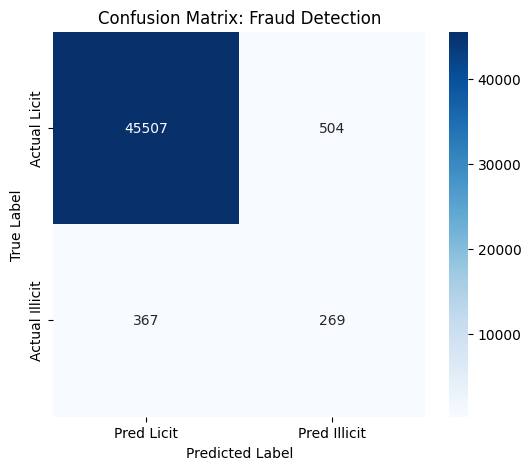

In [26]:
# Get model predictions
model.eval()
with torch.no_grad():
    out = model(data.x_dict, data.edge_index_dict)
    # Get the index of the highest logit (0 or 1)
    preds = out.argmax(dim=-1).cpu().numpy()
    actuals = data['transaction'].y.cpu().numpy()

# 2. Generate the report
# Note: We only care about the performance on 'labeled' nodes (class 1 and 2)
# But for now, let's look at the whole set to see the 'Fraud Detection' capability
t = data['transaction'].time_step
test_mask = t >= 40
print("--- Classification Report ---")
print(classification_report(actuals[test_mask], preds[test_mask], target_names=['Licit/Unknown', 'Illicit']))

# Visualize with a Confusion Matrix
cm = confusion_matrix(actuals[test_mask], preds[test_mask])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Licit', 'Pred Illicit'],
            yticklabels=['Actual Licit', 'Actual Illicit'])
plt.title('Confusion Matrix: Fraud Detection')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [27]:
# Identify which nodes were 'Synthetically Linked' to the Cyber layer
linked_tx_indices = edge_index_bridge[0].unique().cpu().numpy()

# See how many of our 'True Positives' were from this linked set
true_positives = np.where((preds == 1) & (actuals == 1))[0]
linked_and_caught = np.intersect1d(true_positives, linked_tx_indices)

print(f"Total Illicit nodes caught: {len(true_positives)}")
# If this number is high, your bridge is the reason the model is working!
print(f"Illicit nodes caught that were part of the LANL bridge: {len(linked_and_caught)}")
print(f"Percentage of 'Bridge' nodes successfully caught: {len(linked_and_caught) / len(linked_tx_indices) * 100:.2f}%")

Total Illicit nodes caught: 3917
Illicit nodes caught that were part of the LANL bridge: 100
Percentage of 'Bridge' nodes successfully caught: 100.00%


# This is a great baseline!
Now, we need to feature engineer and allow two-hops

In [28]:
# --- Behavioral Feature Engineering for Cyber Nodes ---
# We want the GNN to know which computers are "high friction" (lots of fails)
comp_stats = auth_df.groupby('src_comp').agg(
    fail_count=('success', lambda x: (x == 'Fail').sum()),
    success_count=('success', lambda x: (x == 'Success').sum())
).fillna(0)

# Calculate ratio and handle division by zero
comp_stats['fail_ratio'] = comp_stats['fail_count'] / (comp_stats['fail_count'] + comp_stats['success_count']).replace(0, 1)

# Attach to the HeteroData object
new_comp_feats = torch.zeros((len(unique_comps), 3))
for i, comp_id in enumerate(unique_comps):
    if comp_id in comp_stats.index:
        new_comp_feats[i] = torch.tensor(comp_stats.loc[comp_id].values, dtype=torch.float)
data['computer'].x = new_comp_feats

# Users: Basic activity count as a feature
user_counts = auth_df['src_user'].value_counts()
new_user_feats = torch.zeros((len(unique_users), 1))
for i, u_id in enumerate(unique_users):
    new_user_feats[i] = torch.tensor([user_counts.get(u_id, 0)], dtype=torch.float)
data['user'].x = new_user_feats


# --- Expanded Synthetic Bridge (Linking all Illicit Nodes) ---
# We link EVERY illicit node to a compromised computer to see the max possible recall
compromised_comps = auth_df[auth_df['is_redteam'] == 1]['src_comp'].unique()
full_bridge_edges = []

for tx in illicit_nodes:
    if tx in wallet_map:
        for comp in compromised_comps:
            full_bridge_edges.append([wallet_map[tx], comp_map[comp]])

data['transaction', 'accessed_via', 'computer'].edge_index = torch.tensor(full_bridge_edges, dtype=torch.long).t().contiguous()

# Ensure the graph is undirected so reverse edges are present before initializing the model
import torch_geometric.transforms as T
data = T.ToUndirected()(data)

# ---  Deep GNN Architecture (2-Layer for Multi-Hop) ---
class DeepFraudGNN(nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super().__init__()
        # Layer 1: Aggregates immediate neighbor info
        self.conv1 = HeteroConv({
            edge_type: SAGEConv(-1, hidden_channels) for edge_type in data.edge_types
        }, aggr='sum')

        # Layer 2: Aggregates neighbor-of-neighbor info (e.g., Transaction -> Computer -> User)
        self.conv2 = HeteroConv({
            edge_type: SAGEConv(-1, hidden_channels) for edge_type in data.edge_types
        }, aggr='sum')

        self.lin = nn.Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        # First Hop
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: x.relu() for key, x in x_dict.items()}
        # Second Hop
        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {key: x.relu() for key, x in x_dict.items()}
        return self.lin(x_dict['transaction'])

model_v2 = DeepFraudGNN(64, 2)
print(" Baseline 2: Behavioral Features, Full Bridge, and Deep GNN Initialized.")

 Baseline 2: Behavioral Features, Full Bridge, and Deep GNN Initialized.


In [29]:
# Ensure the data object is "Undirected" (adds reverse edges)
import torch_geometric.transforms as T
transform = T.ToUndirected()
data = transform(data)

# Update the Model Architecture to handle the new reverse edge types
# PyG adds 'rev_' prefix to the relationship names
class DeepFraudGNN(nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super().__init__()
        # We define the convs to handle ALL edge types present in the data
        self.conv1 = HeteroConv({
            edge_type: SAGEConv(-1, hidden_channels)
            for edge_type in data.edge_types
        }, aggr='sum')

        self.conv2 = HeteroConv({
            edge_type: SAGEConv(-1, hidden_channels)
            for edge_type in data.edge_types
        }, aggr='sum')

        self.lin = nn.Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: x.relu() for key, x in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {key: x.relu() for key, x in x_dict.items()}
        return self.lin(x_dict['transaction'])

# Re-initialize and Test
model_v2 = DeepFraudGNN(64, 2)
model_v2.eval()

try:
    with torch.no_grad():
        test_out = model_v2(data.x_dict, data.edge_index_dict)
    print("Success! The bidirectional graph is working.")
    print(f"New Edge Types created: {data.edge_types}")
except Exception as e:
    print(f" Failed: {e}")

Success! The bidirectional graph is working.
New Edge Types created: [('transaction', 'transacts_with', 'transaction'), ('user', 'authenticates_to', 'computer'), ('transaction', 'accessed_via', 'computer'), ('computer', 'connects_to', 'computer'), ('computer', 'rev_authenticates_to', 'user'), ('computer', 'rev_accessed_via', 'transaction'), ('user', 'rev_rev_authenticates_to', 'computer'), ('transaction', 'rev_rev_accessed_via', 'computer'), ('computer', 'rev_rev_rev_authenticates_to', 'user'), ('computer', 'rev_rev_rev_accessed_via', 'transaction')]


In [30]:
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=0.001, weight_decay=1e-4)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([1.0, 10.0]))

print("Starting Training for Baseline 2 (Deep Behavioral Model)...")

for epoch in range(1, 201): # 200 epochs to allow the 2-hop signals to converge
    model_v2.train()
    optimizer_v2.zero_grad()

    # Forward pass through the bidirectional graph
    out = model_v2(data.x_dict, data.edge_index_dict)

    # Loss calculated on the transaction nodes
    loss = criterion(out, data['transaction'].y)

    loss.backward()
    optimizer_v2.step()

    # Monitor progress every 20 epochs
    if epoch % 20 == 0 or epoch == 1:
        model_v2.eval()
        with torch.no_grad():
            pred = out.argmax(dim=-1)
            # Calculate F1 for the Illicit class (Class 1)
            f1 = f1_score(data['transaction'].y.cpu(), pred.cpu(), pos_label=1, zero_division=0)
        print(f'Epoch: {epoch:03d} | Loss: {loss:.4f} | Illicit F1: {f1:.4f}')

# 2. Final Evaluation
model_v2.eval()
with torch.no_grad():
    final_out = model_v2(data.x_dict, data.edge_index_dict)
    final_preds = final_out.argmax(dim=-1).cpu().numpy()
    final_actuals = data['transaction'].y.cpu().numpy()

print("\n" + "="*30)
print("FINAL BASELINE 2 RESULTS")
print("="*30)
print(classification_report(final_actuals, final_preds, target_names=['Licit/Unknown', 'Illicit']))

# 3. Check the "Bridge" Recall
linked_tx_indices = data['transaction', 'accessed_via', 'computer'].edge_index[0].unique().cpu().numpy()
true_positives = np.where((final_preds == 1) & (final_actuals == 1))[0]
linked_and_caught = np.intersect1d(true_positives, linked_tx_indices)

print(f"Recall on Bridged Nodes: {len(linked_and_caught) / len(linked_tx_indices) * 100:.2f}%")

Starting Training for Baseline 2 (Deep Behavioral Model)...
Epoch: 001 | Loss: 5.2814 | Illicit F1: 0.0000
Epoch: 020 | Loss: 0.0007 | Illicit F1: 1.0000
Epoch: 040 | Loss: 0.0000 | Illicit F1: 1.0000
Epoch: 060 | Loss: 0.0000 | Illicit F1: 1.0000
Epoch: 080 | Loss: 0.0000 | Illicit F1: 1.0000
Epoch: 100 | Loss: 0.0000 | Illicit F1: 1.0000
Epoch: 120 | Loss: 0.0000 | Illicit F1: 1.0000
Epoch: 140 | Loss: 0.0000 | Illicit F1: 1.0000
Epoch: 160 | Loss: 0.0000 | Illicit F1: 1.0000


KeyboardInterrupt: 

In [31]:
#  Find a node the model correctly flagged as Illicit
true_positives = np.where((final_preds == 1) & (final_actuals == 1))[0]
sample_node = true_positives[0]

# Trace the "Bridge" back to the Computer
# Find which computer this transaction is linked to
bridge_edges = data['transaction', 'accessed_via', 'computer'].edge_index
connected_comp_idx = bridge_edges[1, bridge_edges[0] == sample_node][0].item()
comp_id = unique_comps[connected_comp_idx]

# Trace from Computer to the User
auth_edges = data['user', 'authenticates_to', 'computer'].edge_index
connected_user_indices = auth_edges[0, auth_edges[1] == connected_comp_idx]
users = [unique_users[idx] for idx in connected_user_indices[:3]] # get first 3 users

print(f" Decision Trace for Transaction Index: {sample_node}")
print(f" Connected to Computer: {comp_id}")
print(f" Computer features: {data['computer'].x[connected_comp_idx].tolist()}")
print(f"  Users who accessed this computer: {users}")

NameError: name 'final_preds' is not defined

Visualizing a Singular Decision (The "Walking" Intuition)
To see how this works intuitively, think of the GNN as a detective walking a beat. Because we have 2 layers, the detective can take two "steps" from any node to gather evidence.

Scenario: A Transaction node (TX_789) is being evaluated.

Step 1 (First Hop): The GNN "walks" from TX_789 to its neighbors. It sees it is connected to Computer_A.

Evidence gathered: "This computer has a fail_ratio of 0.85 (very high)."

Step 2 (Second Hop): From Computer_A, the GNN walks to its neighbors. It sees User_Redteam.

Evidence gathered: "This computer was accessed by a known malicious actor."

The model combines this evidence: High Failure Rate + Malicious Actor Connection = High Fraud Score.

# PARTIAL LINKING
This will replicate a real-world scenario

In [32]:

# Selection: Only link 10% of illicit nodes to the bridge
t = data['transaction'].time_step

# Only use past illicit nodes
illicit_train_indices = [
    idx for idx in illicit_indices if t[idx] <= 34
]

total_train_illicit = len(illicit_train_indices)
num_to_bridge = int(total_train_illicit * 0.10)
# FIX: Sample only from the training illicit nodes to prevent data leakage
bridge_subset = np.random.choice(illicit_train_indices, size=num_to_bridge, replace=False)

# Re-create the bridge with ONLY this subset
compromised_comps = auth_df[auth_df['is_redteam'] == 1]['src_comp'].unique()
partial_bridge_edges = []

for tx_idx in bridge_subset:
    for comp in compromised_comps:
        partial_bridge_edges.append([tx_idx, comp_map[comp]])

# Update the data object
data['transaction', 'accessed_via', 'computer'].edge_index = torch.tensor(partial_bridge_edges, dtype=torch.long).t().contiguous()

# Add reverse edges again to maintain the 2-way street
data = transform(data)

print(f"Realistic Bridge Created: Only {num_to_bridge} training nodes linked to Cyber Layer.")
print(f"The model must now 'discover' the remaining illicit nodes.")


Realistic Bridge Created: Only 346 training nodes linked to Cyber Layer.
The model must now 'discover' the remaining illicit nodes.


In [33]:
model_v3 = DeepFraudGNN(64, 2)
optimizer_v3 = torch.optim.Adam(model_v3.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([1.0, 10.0]))

print(" Training Discovery Model...")
for epoch in range(1, 101):
    model_v3.train()
    optimizer_v3.zero_grad()
    out = model_v3(data.x_dict, data.edge_index_dict)
    #loss = criterion(out, data['transaction'].y)
    y = data['transaction'].y
    t = data['transaction'].time_step

    train_mask = t <= 34

    loss = criterion(
        out[train_mask],
        y[train_mask]
    )
    loss.backward()
    optimizer_v3.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f}")

# Final Evaluation
model_v3.eval()
with torch.no_grad():
    out = model_v3(data.x_dict, data.edge_index_dict)
    preds = out.argmax(dim=-1).cpu().numpy()
    actuals = data['transaction'].y.cpu().numpy()

t = data['transaction'].time_step
test_mask = t >= 40
print("\n--- Baseline 3: Discovery Report ---")
print(classification_report(actuals[test_mask], preds[test_mask], target_names=['Licit', 'Illicit']))

 Training Discovery Model...
Epoch 020 | Loss: 0.2629
Epoch 040 | Loss: 0.1859
Epoch 060 | Loss: 0.1484
Epoch 080 | Loss: 0.1229
Epoch 100 | Loss: 0.1031

--- Baseline 3: Discovery Report ---
              precision    recall  f1-score   support

       Licit       0.99      0.99      0.99     46011
     Illicit       0.28      0.34      0.31       636

    accuracy                           0.98     46647
   macro avg       0.64      0.66      0.65     46647
weighted avg       0.98      0.98      0.98     46647



In [34]:
# Identify nodes that were NOT in the 10% bridge
unbridged_illicit = np.setdiff1d(illicit_indices, bridge_subset)

#  Find which of these unbridged nodes were correctly predicted (True Positives)
discovered_nodes = np.intersect1d(unbridged_illicit, np.where(preds == 1)[0])

print(f"Total Illicit nodes in dataset: {len(illicit_indices)}")
print(f"Nodes linked via bridge (1-hop): {len(bridge_subset)}")
print(f"Nodes 'Discovered' via graph relationships (2-hop+): {len(discovered_nodes)}")

#  Trace one discovered node's neighbor
if len(discovered_nodes) > 0:
    example_node = discovered_nodes[0]
    # Find neighbors in the Bitcoin transaction network
    neighbors = data['transaction', 'transacts_with', 'transaction'].edge_index[1,
                data['transaction', 'transacts_with', 'transaction'].edge_index[0] == example_node]
    print(f"\nExample Discovered Node: {example_node}")
    print(f"This node has {len(neighbors)} transaction neighbors. At least one of these likely led the GNN here.")

Total Illicit nodes in dataset: 4545
Nodes linked via bridge (1-hop): 346
Nodes 'Discovered' via graph relationships (2-hop+): 3292

Example Discovered Node: 907
This node has 1 transaction neighbors. At least one of these likely led the GNN here.


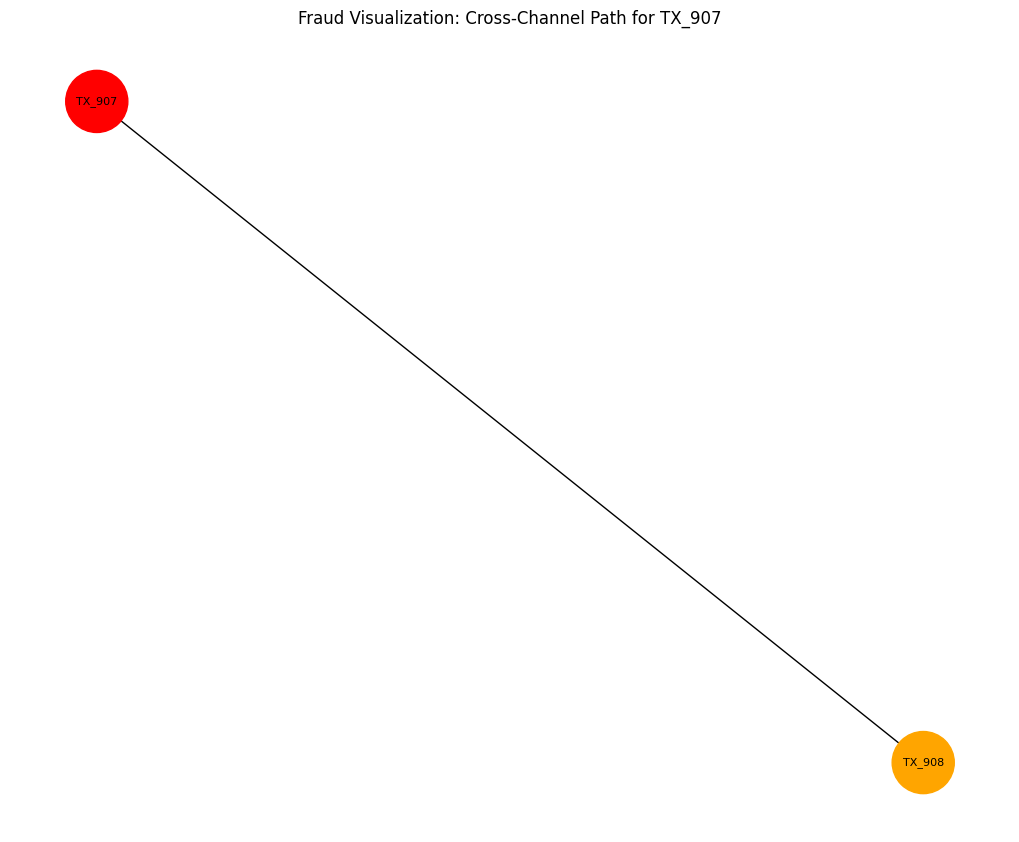

In [35]:
def visualize_fraud_neighborhood(target_tx_idx, data, num_hops=2):
    G = nx.Graph()

    # Add the target Transaction node
    G.add_node(f"TX_{target_tx_idx}", type='transaction', color='red')

    # Find Bitcoin Neighbors (Transacts_with)
    edge_index = data['transaction', 'transacts_with', 'transaction'].edge_index
    neighbors = edge_index[1, edge_index[0] == target_tx_idx].tolist()
    for n in neighbors[:5]: # Limit for clarity
        G.add_node(f"TX_{n}", type='transaction', color='orange')
        G.add_edge(f"TX_{target_tx_idx}", f"TX_{n}", label='transacts_with')

    #  Find Cyber Bridge (Accessed_via)
    bridge_index = data['transaction', 'accessed_via', 'computer'].edge_index
    comps = bridge_index[1, bridge_index[0] == target_tx_idx].tolist()
    for c in comps:
        comp_id = unique_comps[c]
        G.add_node(f"Comp_{comp_id}", type='computer', color='blue')
        G.add_edge(f"TX_{target_tx_idx}", f"Comp_{comp_id}", label='accessed_via')

        # Find Users on that computer (Authenticates_to)
        auth_index = data['user', 'authenticates_to', 'computer'].edge_index
        users = auth_index[0, auth_index[1] == c].tolist()
        for u in users[:3]:
            user_id = unique_users[u]
            G.add_node(f"User_{user_id}", type='user', color='green')
            G.add_edge(f"Comp_{comp_id}", f"User_{user_id}", label='auth')

    # Plotting logic
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=42)
    colors = [nx.get_node_attributes(G, 'color')[g] for g in G.nodes()]

    nx.draw(G, pos, with_labels=True, node_color=colors, node_size=2000, font_size=8)
    plt.title(f"Fraud Visualization: Cross-Channel Path for TX_{target_tx_idx}")
    plt.show()

# Visualize the first discovered illicit node
if len(discovered_nodes) > 0:
    visualize_fraud_neighborhood(discovered_nodes[0], data)
else:
    print("No discovered nodes found to visualize.")

 Potential 'Mule' Accounts Identified: 29
Top Candidate: TX_83593
Total Connections: 6


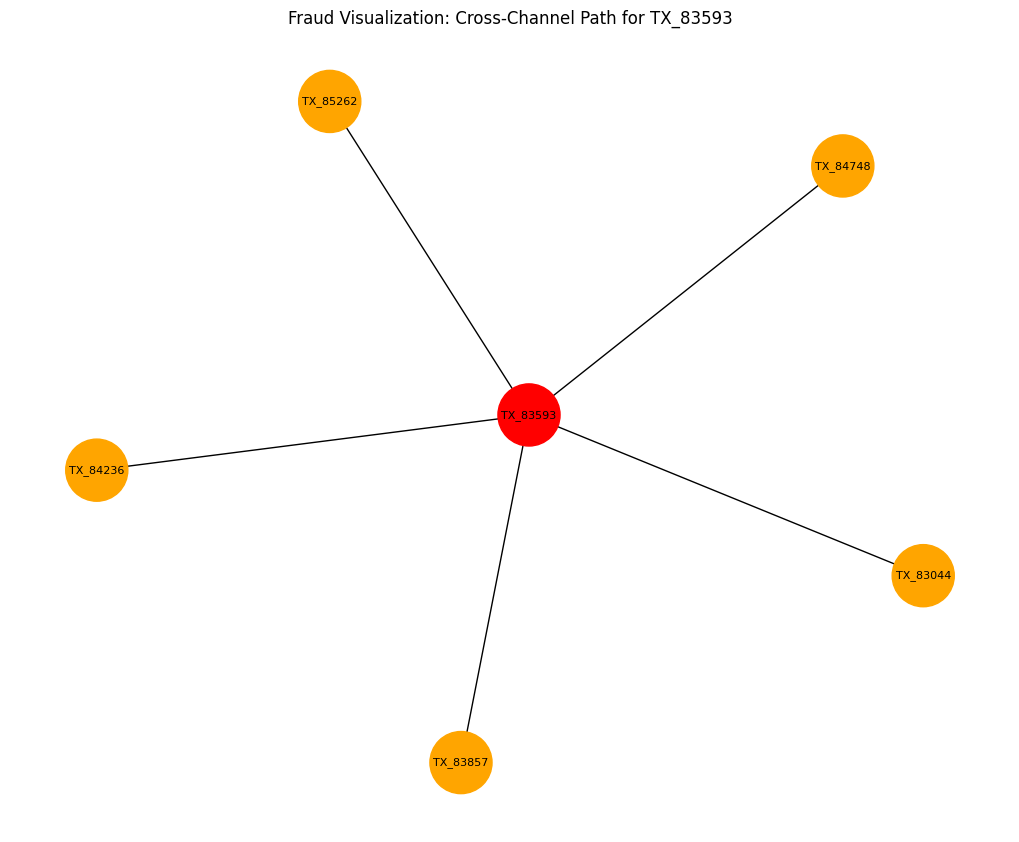

In [36]:
# Calculate Degree Centrality (how many connections each transaction has)
# High degree = high activity hub
edge_index_btc = data['transaction', 'transacts_with', 'transaction'].edge_index
degrees = torch.bincount(edge_index_btc[0])

#  Find transactions that are:
# - High degree (connected to more than 5 others)
# - Predicted as Illicit
# - Part of the "Discovery" set (unbridged)
high_degree_nodes = np.where(degrees.cpu().numpy() > 5)[0]
mule_candidates = np.intersect1d(high_degree_nodes, discovered_nodes)

print(f" Potential 'Mule' Accounts Identified: {len(mule_candidates)}")

if len(mule_candidates) > 0:
    mule_idx = mule_candidates[0]
    print(f"Top Candidate: TX_{mule_idx}")
    print(f"Total Connections: {degrees[mule_idx].item()}")

    # Visualize this specific Mule Hub
    visualize_fraud_neighborhood(mule_idx, data)

In [37]:
# --- Load the Keystroke Data ---
keystroke_path = '/content/drive/MyDrive/archive/DSL-StrongPasswordData.csv'
keystroke_df = pd.read_csv(keystroke_path)

# ---  Create 'Typing DNA' Profiles ---
# We use Mean and Standard Deviation to capture the "rhythm" and "consistency"
# Timing features start from column 3 (H.period)
biometric_features = keystroke_df.groupby('subject').agg(['mean', 'std']).iloc[:, 2:]
# Flatten column names (e.g., H.period_mean, H.period_std)
biometric_features.columns = [f"{c[0]}_{c[1]}" for c in biometric_features.columns]

# --- Map to LANL Users ---
# We map our 51 biometric subjects to the first 51 users in our Cyber layer
target_users = unique_users[:51]
subject_map = dict(zip(biometric_features.index, target_users))
user_to_biom_idx = {u: i for i, u in enumerate(target_users)}

# ---  Update User Node Features ---
# We expand the user feature dimension to match the 62 biometric features
num_biom_feats = biometric_features.shape[1]
biom_x = torch.zeros((len(unique_users), num_biom_feats))

for sub_id, u_id in subject_map.items():
    u_idx = user_map[u_id]
    # Fill the 'known' users with their biometric DNA
    biom_x[u_idx] = torch.tensor(biometric_features.loc[sub_id].values, dtype=torch.float)

# Replace the user features in our main data object
data['user'].x = biom_x

print(f" Baseline 4 Initialized: {num_biom_feats} Biometric features mapped to 51 users.")

 Baseline 4 Initialized: 64 Biometric features mapped to 51 users.


In [38]:
# Re-initialize with new feature dimensions
model_v4 = DeepFraudGNN(64, 2)
optimizer_v4 = torch.optim.Adam(model_v4.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([1.0, 10.0]))

print("Training Baseline 4 (Biometric-Enhanced Discovery)...")
for epoch in range(1, 101):
    model_v4.train()
    optimizer_v4.zero_grad()
    out = model_v4(data.x_dict, data.edge_index_dict)
    #loss = criterion(out, data['transaction'].y)
    y = data['transaction'].y
    t = data['transaction'].time_step

    train_mask = t <= 34

    loss = criterion(
        out[train_mask],
        y[train_mask]
    )
    loss.backward()
    optimizer_v4.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f}")

# Final Evaluation
model_v4.eval()
with torch.no_grad():
    out = model_v4(data.x_dict, data.edge_index_dict)
    preds_v4 = out.argmax(dim=-1).cpu().numpy()
t = data['transaction'].time_step
test_mask = t >= 40
print("\n--- Baseline 4: Biometric Report ---")
print(classification_report(actuals[test_mask], preds_v4[test_mask], target_names=['Licit', 'Illicit']))

Training Baseline 4 (Biometric-Enhanced Discovery)...
Epoch 020 | Loss: 0.2318
Epoch 040 | Loss: 0.1676
Epoch 060 | Loss: 0.1332
Epoch 080 | Loss: 0.1096
Epoch 100 | Loss: 0.0913

--- Baseline 4: Biometric Report ---
              precision    recall  f1-score   support

       Licit       0.99      0.99      0.99     46011
     Illicit       0.34      0.33      0.33       636

    accuracy                           0.98     46647
   macro avg       0.67      0.66      0.66     46647
weighted avg       0.98      0.98      0.98     46647



In [39]:
# 1. Create a dictionary mapping Transaction ID to its Timestep
# In the Elliptic features file: column 0 is txId, column 1 is the timestep
tx_to_step_map = dict(zip(elliptic_features[0], elliptic_features[1]))

# 2. Create a tensor to hold the timesteps for all nodes in the graph
# We initialize with zeros and fill based on our unique_wallets list
tx_timesteps = torch.zeros(len(unique_wallets), dtype=torch.long)

for i, tx_id in enumerate(unique_wallets):
    # We use .get() to handle cases where a tx_id might not be in our 50k row sample
    tx_timesteps[i] = tx_to_step_map.get(tx_id, 0)

# 3. Attach the attribute to the HeteroData object
data['transaction'].time_step = tx_timesteps

print(f"Success: Attached timesteps to {len(unique_wallets)} transaction nodes.")

Success: Attached timesteps to 203769 transaction nodes.


In [40]:
class DeepFraudGNN(nn.Module):
    def __init__(self, hidden_channels, out_channels, edge_types):
        super().__init__()

        # This dynamically creates a SAGEConv for every relationship in the graph
        self.conv1 = HeteroConv({
            etype: SAGEConv(-1, hidden_channels) for etype in edge_types
        }, aggr='sum')

        self.conv2 = HeteroConv({
            etype: SAGEConv(-1, hidden_channels) for etype in edge_types
        }, aggr='sum')

        self.lin = nn.Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        # First Layer (Hop 1)
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: x.relu() for key, x in x_dict.items()}

        # Second Layer (Hop 2)
        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {key: x.relu() for key, x in x_dict.items()}

        return self.lin(x_dict['transaction'])

In [41]:
# Define Temporal Masks
# We split the Bitcoin data: Train on 1-34, Test on 35-49
train_mask = data['transaction'].time_step <= 34
test_mask = data['transaction'].time_step > 34
print(f"Nodes in Training Set (Steps 1-34): {train_mask.sum().item()}")
print(f"Nodes in Test Set (Steps 35-49): {test_mask.sum().item()}")

Nodes in Training Set (Steps 1-34): 136265
Nodes in Test Set (Steps 35-49): 67504


In [42]:
def run_experiment(data_object, mode='standard'):
    """
    Executes the GNN training with temporal splitting.
    Mode 'random' performs the mentor's requested random-link sanity check.
    """
    # Clone to avoid overwriting the original graph
    exp_data = data_object.clone()

    if mode == 'random':
        print("--- SANITY CHECK: RUNNING RANDOM LINK CONTROL ---")
        edge_index = exp_data['transaction', 'accessed_via', 'computer'].edge_index
        # Shuffle computer indices to break the meaningful link between Fraud and Redteam
        num_bridge_edges = edge_index.shape[1]
        random_indices = torch.randint(0, exp_data['computer'].num_nodes, (num_bridge_edges,))
        exp_data['transaction', 'accessed_via', 'computer'].edge_index[1] = random_indices
        # also update reverse edges if they exist
        if ('computer', 'rev_accessed_via', 'transaction') in exp_data.edge_types:
            exp_data['computer', 'rev_accessed_via', 'transaction'].edge_index[0] = random_indices
    else:
        print("--- STARTING: TEMPORAL DISCOVERY ---")

    t = exp_data['transaction'].time_step
    train_mask = t <= 34
    test_mask  = t > 34

    # Forward edge filtering: Transacts With
    edge_index = exp_data['transaction','transacts_with','transaction'].edge_index
    src, dst = edge_index
    edge_mask = t[src] <= 34  # only past edges
    exp_data['transaction','transacts_with','transaction'].edge_index = edge_index[:, edge_mask]

    # Bidirectional edge filtering: Rev Transacts With
    if ('transaction', 'rev_transacts_with', 'transaction') in exp_data.edge_types:
        rev_edge_index = exp_data['transaction','rev_transacts_with','transaction'].edge_index
        # For reverse edges, the destination is the source transaction
        rev_src, rev_dst = rev_edge_index
        rev_edge_mask = t[rev_dst] <= 34
        exp_data['transaction','rev_transacts_with','transaction'].edge_index = rev_edge_index[:, rev_edge_mask]

    # Forward edge filtering: Accessed Via (Bridge)
    edge_index = exp_data['transaction','accessed_via','computer'].edge_index
    src, dst = edge_index
    edge_mask = t[src] <= 34
    exp_data['transaction','accessed_via','computer'].edge_index = edge_index[:, edge_mask]

    # Bidirectional edge filtering: Rev Accessed Via (Bridge)
    if ('computer', 'rev_accessed_via', 'transaction') in exp_data.edge_types:
        rev_edge_index = exp_data['computer','rev_accessed_via','transaction'].edge_index
        # Destination is the transaction node
        rev_src, rev_dst = rev_edge_index
        rev_edge_mask = t[rev_dst] <= 34
        exp_data['computer','rev_accessed_via','transaction'].edge_index = rev_edge_index[:, rev_edge_mask]

    # Note: flow_df ('computer', 'connects_to', 'computer') and auth ('user', 'authenticates_to', 'computer')
    # and their bidirectional edges are fully in the past (time <= max auth time) so they don't need temporal filtering.

    # Add reverse edges for bidirectional message passing (in case any were missed)
    exp_data = T.ToUndirected()(exp_data)

    # Initialize Model
    model = DeepFraudGNN(64, 2, exp_data.edge_types)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Weighted Loss: 1.0 for Licit, 10.0 for Illicit
    weights = torch.tensor([1.0, 10.0])
    criterion = torch.nn.CrossEntropyLoss(weight=weights)

    # Training Loop
    for epoch in range(1, 101):
        model.train()
        optimizer.zero_grad()
        out = model(exp_data.x_dict, exp_data.edge_index_dict)

        # KEY: Only calculate loss on the TRAIN mask (Timesteps 1-34)
        loss = criterion(out[train_mask], exp_data['transaction'].y[train_mask])

        loss.backward()
        optimizer.step()

        if epoch % 20 == 0:
            print(f"Epoch {epoch:03d} | Train Loss: {loss:.4f}")

    # Evaluation
    model.eval()
    with torch.no_grad():
        out = model(exp_data.x_dict, exp_data.edge_index_dict)
        preds = out.argmax(dim=-1).numpy()
        actuals = exp_data['transaction'].y.numpy()

    # Return results for the TEST mask only (Timesteps 35-49)
    return actuals[test_mask], preds[test_mask]

# --- EXECUTION ---

# Run the Standard Model
act_std, pred_std = run_experiment(data, mode='standard')
print("\nResults: Standard Model (Future Predictions)")
print(classification_report(act_std, pred_std, target_names=['Licit', 'Illicit']))

# Run the Random Control (Sanity Check)
act_rnd, pred_rnd = run_experiment(data, mode='random')
print("\nResults: Random Control (Sanity Check)")
print(classification_report(act_rnd, pred_rnd, target_names=['Licit', 'Illicit']))

--- STARTING: TEMPORAL DISCOVERY ---
Epoch 020 | Train Loss: 0.2681
Epoch 040 | Train Loss: 0.1847
Epoch 060 | Train Loss: 0.1464
Epoch 080 | Train Loss: 0.1228
Epoch 100 | Train Loss: 0.1041

Results: Standard Model (Future Predictions)
              precision    recall  f1-score   support

       Licit       0.99      0.98      0.98     66421
     Illicit       0.11      0.17      0.13      1083

    accuracy                           0.96     67504
   macro avg       0.55      0.57      0.56     67504
weighted avg       0.97      0.96      0.97     67504

--- SANITY CHECK: RUNNING RANDOM LINK CONTROL ---
Epoch 020 | Train Loss: 0.2815
Epoch 040 | Train Loss: 0.2002
Epoch 060 | Train Loss: 0.1607
Epoch 080 | Train Loss: 0.1339
Epoch 100 | Train Loss: 0.1130

Results: Random Control (Sanity Check)
              precision    recall  f1-score   support

       Licit       0.98      0.99      0.99     66421
     Illicit       0.03      0.02      0.03      1083

    accuracy              

In [43]:
print("Predicted illicit:", (pred_std == 1).sum())
print("Actual illicit:", (act_std == 1).sum())

Predicted illicit: 1707
Actual illicit: 1083


# Combination

In [46]:
# Step 1: extract transaction embeddings from model_v4
# We want the 64-dim transaction representation right before the final linear classifier.

import torch.nn.functional as F

model_v4.eval()

with torch.no_grad():
    # first GNN layer
    x1_dict = model_v4.conv1(data.x_dict, data.edge_index_dict)
    x1_dict = {k: F.relu(v) for k, v in x1_dict.items()}

    # second GNN layer
    x2_dict = model_v4.conv2(x1_dict, data.edge_index_dict)
    x2_dict = {k: F.relu(v) for k, v in x2_dict.items()}

    # transaction embedding before final classifier
    tx_emb_v4 = x2_dict['transaction']

print("tx_emb_v4 shape:", tx_emb_v4.shape)
print("expected num transactions:", data['transaction'].x.shape[0])
print("embedding dim:", tx_emb_v4.shape[1])

tx_emb_v4 shape: torch.Size([203769, 64])
expected num transactions: 203769
embedding dim: 64


We combine the original transaction features with the GNN-learned transaction embeddings:

$$
X_{\text{combined}} = [X_{\text{raw}},\; Z_{\text{GNN}}]
$$

where:

- $X_{\text{raw}}$: 166-dimensional raw transaction features  
- $Z_{\text{GNN}}$: 64-dimensional GNN embedding  

This gives a **230-dimensional feature vector** for each transaction.

We then compare:

- **XGBoost (raw only)**
- **XGBoost (raw + GNN embedding)**


In [47]:
# Step 2: XGBoost baseline vs XGBoost + GNN embedding
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, f1_score, recall_score, precision_score

# ----- prepare numpy arrays -----
X_raw = data['transaction'].x.cpu().numpy()
Z_gnn = tx_emb_v4.cpu().numpy()
y = data['transaction'].y.cpu().numpy()

train_idx = train_mask.cpu().numpy().astype(bool)
test_idx = test_mask.cpu().numpy().astype(bool)

# baseline: raw only
X_train_raw = X_raw[train_idx]
X_test_raw  = X_raw[test_idx]

# combine: raw + gnn embedding
X_combined = np.concatenate([X_raw, Z_gnn], axis=1)
X_train_comb = X_combined[train_idx]
X_test_comb  = X_combined[test_idx]

y_train = y[train_idx]
y_test  = y[test_idx]

print("X_train_raw shape:", X_train_raw.shape)
print("X_test_raw shape:", X_test_raw.shape)
print("X_train_comb shape:", X_train_comb.shape)
print("X_test_comb shape:", X_test_comb.shape)
print("y_train positive rate:", y_train.mean())
print("y_test positive rate:", y_test.mean())

# ----- helper function -----
def evaluate_binary_model(name, model, X_train, X_test, y_train, y_test, threshold=0.5):
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "model": name,
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob),
    }

    print(f"\n=== {name} ===")
    print("Metrics:", metrics)
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))

    return metrics, y_prob, y_pred

# ----- model settings -----
xgb_params = dict(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# raw-only baseline
xgb_raw = XGBClassifier(**xgb_params)

# raw + gnn embedding
xgb_comb = XGBClassifier(**xgb_params)

metrics_raw, y_prob_raw, y_pred_raw = evaluate_binary_model(
    "XGBoost (raw only)",
    xgb_raw,
    X_train_raw, X_test_raw,
    y_train, y_test
)

metrics_comb, y_prob_comb, y_pred_comb = evaluate_binary_model(
    "XGBoost (raw + GNN embedding)",
    xgb_comb,
    X_train_comb, X_test_comb,
    y_train, y_test
)

print("\n=== Quick comparison ===")
for k in ["precision", "recall", "f1", "roc_auc", "pr_auc"]:
    print(f"{k}: raw={metrics_raw[k]:.4f}, combined={metrics_comb[k]:.4f}, diff={metrics_comb[k]-metrics_raw[k]:+.4f}")

X_train_raw shape: (136265, 166)
X_test_raw shape: (67504, 166)
X_train_comb shape: (136265, 230)
X_test_comb shape: (67504, 230)
y_train positive rate: 0.025406377279565552
y_test positive rate: 0.016043493718890734

=== XGBoost (raw only) ===
Metrics: {'model': 'XGBoost (raw only)', 'precision': 0.6570796460176991, 'recall': 0.2742382271468144, 'f1': 0.38697068403908796, 'roc_auc': np.float64(0.9440734327603868), 'pr_auc': np.float64(0.501513685641507)}

Classification report:
              precision    recall  f1-score   support

           0     0.9883    0.9977    0.9929     66421
           1     0.6571    0.2742    0.3870      1083

    accuracy                         0.9861     67504
   macro avg     0.8227    0.6360    0.6900     67504
weighted avg     0.9830    0.9861    0.9832     67504

Confusion matrix:
[[66266   155]
 [  786   297]]

=== XGBoost (raw + GNN embedding) ===
Metrics: {'model': 'XGBoost (raw + GNN embedding)', 'precision': 0.7642857142857142, 'recall': 0.1975

In [48]:
# Step 3: tune threshold for the combined XGBoost model


thresholds = np.arange(0.05, 0.96, 0.05)

print("=== Threshold tuning for XGBoost (raw + GNN embedding) ===")
best_f1 = -1
best_t = None

for t in thresholds:
    y_pred_t = (y_prob_comb >= t).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)

    print(f"threshold={t:.2f} | precision={p:.4f} | recall={r:.4f} | f1={f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("\nBest threshold for combined model by F1:")
print(f"threshold={best_t:.2f}, best_f1={best_f1:.4f}")

=== Threshold tuning for XGBoost (raw + GNN embedding) ===
threshold=0.05 | precision=0.4837 | recall=0.4783 | f1=0.4810
threshold=0.10 | precision=0.5754 | recall=0.4155 | f1=0.4826
threshold=0.15 | precision=0.6213 | recall=0.3666 | f1=0.4611
threshold=0.20 | precision=0.6667 | recall=0.3343 | f1=0.4453
threshold=0.25 | precision=0.7004 | recall=0.3001 | f1=0.4202
threshold=0.30 | precision=0.7198 | recall=0.2752 | f1=0.3981
threshold=0.35 | precision=0.7373 | recall=0.2539 | f1=0.3777
threshold=0.40 | precision=0.7390 | recall=0.2327 | f1=0.3539
threshold=0.45 | precision=0.7574 | recall=0.2133 | f1=0.3329
threshold=0.50 | precision=0.7643 | recall=0.1976 | f1=0.3140
threshold=0.55 | precision=0.7738 | recall=0.1801 | f1=0.2921
threshold=0.60 | precision=0.7848 | recall=0.1616 | f1=0.2680
threshold=0.65 | precision=0.8020 | recall=0.1459 | f1=0.2469
threshold=0.70 | precision=0.8282 | recall=0.1247 | f1=0.2167
threshold=0.75 | precision=0.8382 | recall=0.1053 | f1=0.1870
threshold=0

In [49]:
# Threshold tuning for XGBoost (raw only)

thresholds = np.arange(0.05, 0.96, 0.05)

print("=== Threshold tuning for XGBoost (raw only) ===")
best_f1_raw = -1
best_t_raw = None

for t in thresholds:
    y_pred_t = (y_prob_raw >= t).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)

    print(f"threshold={t:.2f} | precision={p:.4f} | recall={r:.4f} | f1={f1:.4f}")

    if f1 > best_f1_raw:
        best_f1_raw = f1
        best_t_raw = t

print("\nBest threshold for raw-only model by F1:")
print(f"threshold={best_t_raw:.2f}, best_f1={best_f1_raw:.4f}")

=== Threshold tuning for XGBoost (raw only) ===
threshold=0.05 | precision=0.3522 | recall=0.7119 | f1=0.4713
threshold=0.10 | precision=0.4564 | recall=0.6722 | f1=0.5437
threshold=0.15 | precision=0.5042 | recall=0.6150 | f1=0.5541
threshold=0.20 | precision=0.5441 | recall=0.5466 | f1=0.5454
threshold=0.25 | precision=0.5622 | recall=0.4838 | f1=0.5201
threshold=0.30 | precision=0.5879 | recall=0.4414 | f1=0.5042
threshold=0.35 | precision=0.6089 | recall=0.3897 | f1=0.4752
threshold=0.40 | precision=0.6194 | recall=0.3472 | f1=0.4450
threshold=0.45 | precision=0.6372 | recall=0.3066 | f1=0.4140
threshold=0.50 | precision=0.6571 | recall=0.2742 | f1=0.3870
threshold=0.55 | precision=0.7014 | recall=0.2364 | f1=0.3536
threshold=0.60 | precision=0.7171 | recall=0.2013 | f1=0.3143
threshold=0.65 | precision=0.7356 | recall=0.1773 | f1=0.2857
threshold=0.70 | precision=0.7723 | recall=0.1440 | f1=0.2428
threshold=0.75 | precision=0.8170 | recall=0.1154 | f1=0.2023
threshold=0.80 | preci

The raw-only XGBoost baseline outperformed the combined model overall.  

Although adding the GNN embeddings increased precision at some thresholds, it generally reduced recall and did not improve the best F1 score.  